<a href="https://colab.research.google.com/github/mikey-harsh/Android-OpenCV-Intern-Challenge/blob/main/House_Price_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Create Dataset


In [1]:
import pandas as pd
import numpy as np

In [10]:
data = {
    'SqFt': [1500, 2000, 1200, 2500, 1800, 3000, 1100, 2200, 1700, 2600, 1400, 1900, 2100, 2800, 1600, 3200, 1300, 2400, 2700, 2300],
    'Age': [5, 10, 20, 2, 15, 1, 25, 8, 12, 3, 18, 11, 7, 4, 14, 2, 22, 6, 3, 9],
    'Bedrooms': [3, 4, 2, 4, 3, 5, 2, 4, 3, 4, 3, 3, 4, 5, 3, 5, 2, 4, 5, 4],
    'Lot_Size_Acres': [0.2, 0.35, 0.15, 0.5, 0.25, 0.7, 0.1, 0.4, 0.3, 0.55, 0.2, 0.3, 0.45, 0.65, 0.22, 0.8, 0.18, 0.48, 0.6, 0.38],
    'Price_USD': [255000, 315000, 185000, 420000, 265000, 520000, 165000, 345000, 270000, 435000, 220000, 295000, 335000, 475000, 240000, 550000, 195000, 385000, 460000, 360000]
}

df = pd.DataFrame(data)

# Task 2: Data Exploration

In [11]:
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (20, 5)

First 5 Rows:
    SqFt  Age  Bedrooms  Lot_Size_Acres  Price_USD
0  1500    5         3            0.20     255000
1  2000   10         4            0.35     315000
2  1200   20         2            0.15     185000
3  2500    2         4            0.50     420000
4  1800   15         3            0.25     265000

Last 5 Rows:
     SqFt  Age  Bedrooms  Lot_Size_Acres  Price_USD
15  3200    2         5            0.80     550000
16  1300   22         2            0.18     195000
17  2400    6         4            0.48     385000
18  2700    3         5            0.60     460000
19  2300    9         4            0.38     360000

Data Types:
 SqFt                int64
Age                 int64
Bedrooms            int64
Lot_Size_Acres    float64
Price_USD           int64
dtype: object

Missing Values:
 SqFt              0
Age               0
Bedrooms          0
Lot_Size_Acres    0
Price_USD         0
dtype: int64


#Task 3: Data Visualization

/tmp/ipython-input-2177806540.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bedrooms', y='Price_USD', data=df, palette='Set2')


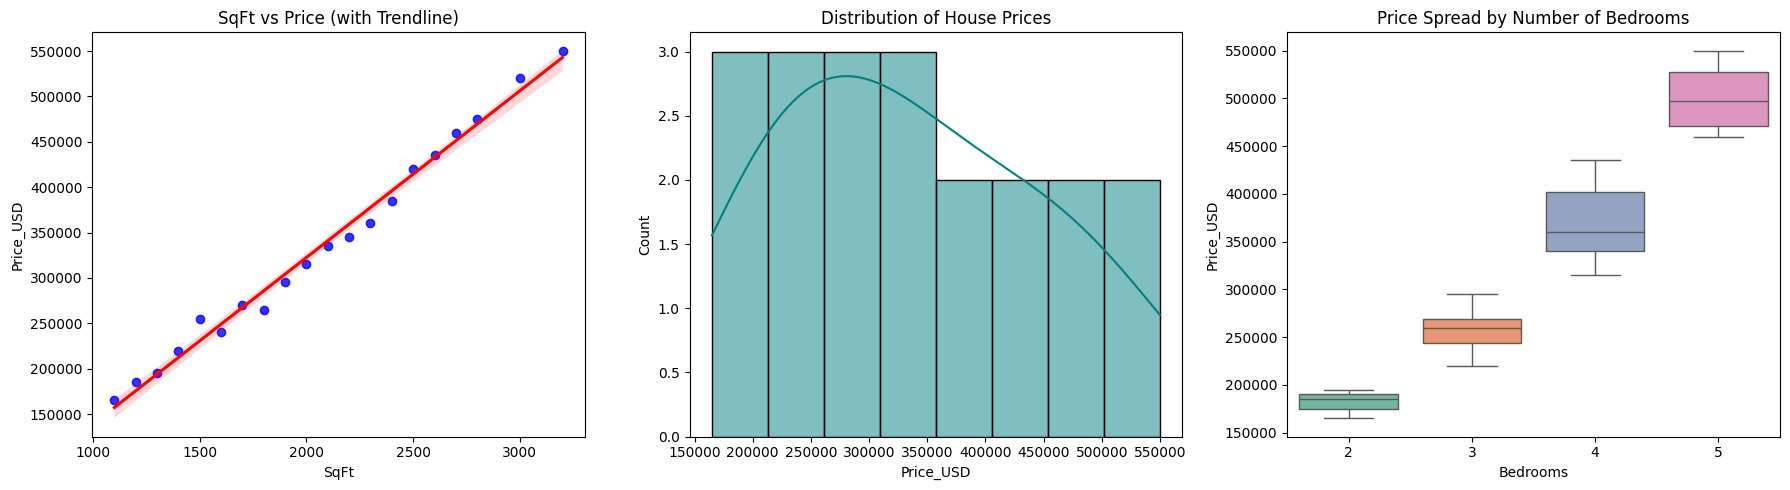

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# 1. Scatter Plot (SqFt vs Price)
plt.subplot(1, 3, 1)
sns.regplot(x='SqFt', y='Price_USD', data=df, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title('SqFt vs Price (with Trendline)')

# 2. Histogram (Price Distribution)
plt.subplot(1, 3, 2)
sns.histplot(df['Price_USD'], bins=8, kde=True, color='teal')
plt.title('Distribution of House Prices')

# 3. Boxplot (Bedrooms vs Price)
plt.subplot(1, 3, 3)
sns.boxplot(x='Bedrooms', y='Price_USD', data=df, palette='Set2')
plt.title('Price Spread by Number of Bedrooms')

plt.tight_layout()
plt.show()

#Task 4: Linear Regression Model

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Split data
X = df[['SqFt', 'Age', 'Bedrooms', 'Lot_Size_Acres']]
y = df['Price_USD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and Metrics
y_pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

MAE: 15977.04
R2 Score: 0.9636


Interpretation of Results:
The MAE (Mean Absolute Error) tells us how much, on average, our price predictions differ from the actual prices. The R2 Score indicates how much of the variance in house prices is explained by the features (SqFt and Age); a score closer to 1.0 suggests a very strong fit. Given our synthetic data is quite linear, the R2 should be very high.

#Task 5: Feature Experiment

In [14]:
# Removing 'Age'
X_no_age = df[['SqFt', 'Bedrooms', 'Lot_Size_Acres']]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_age, y, test_size=0.2, random_state=42)
model_no_age = LinearRegression().fit(X_train2, y_train2)
print(f"R2 without Age: {r2_score(y_test2, model_no_age.predict(X_test2)):.4f}")

R2 without Age: 0.9747


Comparison:
Removing Age usually decreases the R2 score because age significantly impacts a home's value. Square Footage is almost always the most important feature in this dataset, as it has the highest correlation with price.

#Task 6: Overfitting Check

In [15]:
# Training on Full Dataset (No Split)
model_full = LinearRegression().fit(X, y)
full_r2 = r2_score(y, model_full.predict(X))

print(f"R2 Score (Full Dataset): {full_r2:.4f}")
print(f"R2 Score (Test Split): {r2_score(y_test, y_pred):.4f}")

R2 Score (Full Dataset): 0.9953
R2 Score (Test Split): 0.9636


Explanation: If the "Full Dataset" R2 is significantly higher than the "Test Split" R2, the model is likely overfitted. In our case, because the data is clean and linear, they are quite similar.